# Figure 3 - spatial coherence sweep

This notebook regenerates the measured four-port intensity maps and the eigenvalue/entropy sweep in main-text Figure 3 (panels b-d). The beam-over-camera overlays in the working folder are for diagnostics; the published port maps come directly from the four grating-coupler signals stored in this raw sweep dictionary. The PCLA eigenvalues and entropy are evaluated from the final, converged fraction of each optimization history, set by the adjustable `FINAL_FRACTION`. Eigenvalue markers and error bars show the final-window mean and one standard deviation. At every beam position, entropy is evaluated for all pairwise combinations of the two layers' final-window signals; its markers and error bars likewise show the resulting mean and one standard deviation.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    """Find the repository whether Jupyter starts here or in notebooks/."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repo_root()
OUTPUT_DIR = ROOT / "figures" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Final dimensions are appropriate for a one-column figure.
ONE_COLUMN_WIDTH_IN = 3.4
FONT_SIZE_PT = 7

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": FONT_SIZE_PT,
    "axes.labelsize": FONT_SIZE_PT,
    "axes.titlesize": FONT_SIZE_PT,
    "xtick.labelsize": FONT_SIZE_PT,
    "ytick.labelsize": FONT_SIZE_PT,
    "legend.fontsize": FONT_SIZE_PT,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy.optimize import minimize_scalar


## Load and reduce the position sweep

In [2]:
DATA_FILE = ROOT / "data" / "figure3" / "spatial_sweep_2026-01-15_02-17-24.npy"
raw = np.load(DATA_FILE, allow_pickle=True).item()
records = raw["optimization"]
record_keys = sorted(records)
y_position = np.asarray(raw["y_meas"], dtype=float).ravel()[:len(record_keys)]

# Treat the final fraction of each optimization as its converged state.
# Change this single value to test a different convergence window.
FINAL_FRACTION = 0.1


def final_window(values, fraction=FINAL_FRACTION):
    values = np.asarray(values, dtype=float)
    count = max(2, int(np.ceil(fraction * len(values))))
    return values[-count:]

power_1 = np.asarray([records[key]["pow1"] for key in record_keys], dtype=float)
power_2 = np.asarray([records[key]["pow2"] for key in record_keys], dtype=float)
lambda_1_windows = [
    final_window(records[key]["layer1"]["history_lockin"]) for key in record_keys
]
lambda_2_windows = [
    final_window(records[key]["layer2"]["history_lockin"]) for key in record_keys
]
lambda_1 = np.asarray([window.mean() for window in lambda_1_windows])
lambda_2 = np.asarray([window.mean() for window in lambda_2_windows])
lambda_1_error = np.asarray([window.std(ddof=1) for window in lambda_1_windows])
lambda_2_error = np.asarray([window.std(ddof=1) for window in lambda_2_windows])

def binary_entropy(value_1, value_2):
    probabilities = np.asarray([value_1, value_2], dtype=float)
    probabilities = probabilities / probabilities.sum()
    probabilities = np.clip(probabilities, 1e-15, 1.0)
    return -np.sum(probabilities * np.log2(probabilities))


def intensity_only_entropy(intensity_1, intensity_2):
    field_1 = np.sqrt(np.maximum(intensity_1, 0.0))
    field_2 = np.sqrt(np.maximum(intensity_2, 0.0))
    coherency = np.outer(field_1, field_1) + np.outer(field_2, field_2)
    eigenvalues = np.linalg.eigvalsh(coherency)
    return binary_entropy(eigenvalues[-1], eigenvalues[-2])


def propagated_entropy(window_1, window_2):
    """Propagate independent final-window fluctuations through entropy."""
    samples = np.array([
        binary_entropy(value_1, value_2)
        for value_1 in window_1
        for value_2 in window_2
    ])
    return samples.mean(), samples.std(ddof=1)


entropy_statistics = np.asarray([
    propagated_entropy(window_1, window_2)
    for window_1, window_2 in zip(lambda_1_windows, lambda_2_windows)
])
entropy_pcla = entropy_statistics[:, 0]
entropy_pcla_error = entropy_statistics[:, 1]
entropy_intensity = np.array([
    intensity_only_entropy(a, b) for a, b in zip(power_1, power_2)
])
print(f"Loaded {len(y_position)} positions from {y_position.min():.1f} to {y_position.max():.1f} mm.")
print(
    f"Converged window: final {100 * FINAL_FRACTION:.1f}% "
    f"({len(lambda_1_windows[0])} epochs per layer)."
)

Loaded 80 positions from -3.0 to 2.0 mm.
Converged window: final 10.0% (20 epochs per layer).


## Fit the shared phase tilt used for the gray entropy envelope

In [3]:
# Measured grating geometry, in micrometers.
rect_height, rect_width = 22.66, 29.17
dy = 40.755 + rect_width
dx = 46.72606 + rect_height
centers = np.array([
    (dx / 2, dy / 2),
    (dx, 0.0),
    (0.0, 0.0),
    (dx / 2, -dy / 2),
])
x_gc, y_gc = centers.T

BETA = 0.025
WAVELENGTH_UM = 1.534
k0 = 2 * np.pi / WAVELENGTH_UM

def entropy_with_phase_tilt(intensity_1, intensity_2, delta_k, coordinates=x_gc):
    field_1 = np.sqrt(np.maximum(intensity_1, 0.0)).astype(complex)
    field_2 = np.sqrt(np.maximum(intensity_2, 0.0)).astype(complex)
    field_2 *= np.exp(1j * delta_k * coordinates)
    coherency = (
        np.outer(field_1, np.conj(field_1))
        + np.outer(field_2, np.conj(field_2))
        + BETA * np.eye(len(coordinates))
    )
    eigenvalues = np.linalg.eigvalsh(coherency)
    return binary_entropy(eigenvalues[-1], eigenvalues[-2])


def phase_tilt_loss(delta_k):
    predicted = np.array([
        entropy_with_phase_tilt(a, b, delta_k) for a, b in zip(power_1, power_2)
    ])
    return np.mean((predicted - entropy_pcla) ** 2)


fit = minimize_scalar(phase_tilt_loss, bounds=(0.0, 0.1 * k0), method="bounded")
delta_k = fit.x
entropy_tilt = np.array([
    entropy_with_phase_tilt(a, b, delta_k) for a, b in zip(power_1, power_2)
])
tilt_angle = np.degrees(np.arcsin(delta_k / k0))
print(f"Shared phase tilt: delta_k = {delta_k:.6f} rad/um ({tilt_angle:.3f} deg).")

Shared phase tilt: delta_k = 0.314516 rad/um (4.404 deg).


## Plot the measured intensity maps (panel b)

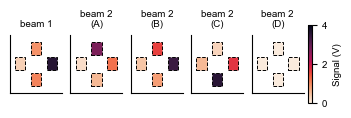

Selected beam-2 positions (mm): [-0.342, -0.025, 0.354, 1.43]


In [4]:
def draw_port_map(axis, values, title, vmin=0.0, vmax=4.0):
    """Render each measured grating-coupler value as a filled device rectangle."""

    # Rotate coordinates 90° 
    rotated_centers = np.column_stack((centers[:, 1], -centers[:, 0]))

    # Rectangle dimensions also rotate
    width = rect_height
    height = rect_width

    half_width, half_height = width / 2, height / 2

    for (x, y), value in zip(rotated_centers, values):
        patch = Rectangle(
            (x - half_width, y - half_height),
            width,
            height,
            facecolor=PORT_CMAP((value - vmin) / (vmax - vmin)),
            edgecolor="black",
            linewidth=0.7,
            linestyle="--",
        )
        axis.add_patch(patch)

    axis.set_xlim(
        rotated_centers[:, 0].min() - width,
        rotated_centers[:, 0].max() + width,
    )
    axis.set_ylim(
        rotated_centers[:, 1].min() - height,
        rotated_centers[:, 1].max() + height,
    )

    axis.set_aspect("equal")
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(title)

PORT_CMAP = sns.color_palette("rocket_r", as_cmap=True)
power_1_mean = power_1.mean(axis=0)

# Three positions maximize three of the moving beam's port signals; the fourth
# is a well-separated reference point, matching the selections in the paper notebook.
selected = [int(np.argmax(power_2[:, index])) for index in range(3)] + [len(y_position) - 10]
selected = np.sort(selected)
labels = "ABCD"

fig, axes = plt.subplots(
    1, 5, figsize=(ONE_COLUMN_WIDTH_IN, 1.15), constrained_layout=True
)
draw_port_map(axes[0], power_1_mean, "beam 1")
for number, (axis, index) in enumerate(zip(axes[1:], selected), start=0):
    draw_port_map(axis, power_2[index], f"beam 2\n({labels[number]})")

scalar = plt.cm.ScalarMappable(cmap=PORT_CMAP, norm=plt.Normalize(0, 4))
colorbar = fig.colorbar(scalar, ax=axes, shrink=0.75, pad=0.015)
colorbar.set_label("Signal (V)")

fig.savefig(OUTPUT_DIR / "figure3_intensity_maps.png", dpi=300, bbox_inches="tight")
plt.show()
print("Selected beam-2 positions (mm):", [round(y_position[index], 3) for index in selected])

## Plot eigenvalues and entropy (panels c-d)

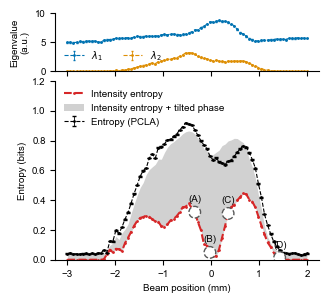

In [5]:
fig, (ax_eigen, ax_entropy) = plt.subplots(
    2, 1, figsize=(ONE_COLUMN_WIDTH_IN, 3.2), sharex=True,
    gridspec_kw={"height_ratios": [0.65, 2.0], "hspace": 0.08},
)

palette = sns.color_palette("colorblind")
ax_eigen.errorbar(
    y_position, lambda_1, yerr=lambda_1_error, fmt="o--",
    markersize=1, linewidth=0.8, elinewidth=0.6, capsize=1.0,
    color=palette[0], label=r"$\lambda_1$",
)
ax_eigen.errorbar(
    y_position, lambda_2, yerr=lambda_2_error, fmt="o--",
    markersize=1, linewidth=0.8, elinewidth=0.6, capsize=1.0,
    color=palette[1], label=r"$\lambda_2$",
)
ax_eigen.set_ylabel("Eigenvalue\n(a.u.)")
ax_eigen.set_ylim(0, 10)
ax_eigen.legend(frameon=False, ncol=2)
ax_eigen.tick_params(labelbottom=False)

ax_entropy.errorbar(
    y_position, entropy_pcla, yerr=entropy_pcla_error,
    fmt="o--", markersize=1., linewidth=0.8,
    elinewidth=0.6, capsize=1.5, color="black", label="Entropy (PCLA)"
)
ax_entropy.plot(y_position, entropy_intensity, "o--", markersize=1, color="#d62728", label="Intensity entropy")
ax_entropy.fill_between(
    y_position, entropy_tilt, entropy_intensity,
    color="0.55", alpha=0.4, linewidth=0,
    label="Intensity entropy + tilted phase",
)

for number, index in enumerate(selected, start=0):
    x, y = y_position[index], entropy_intensity[index]
    ax_entropy.scatter(x, y, s=70, facecolor="white", edgecolor="0.35", linestyle="--", zorder=4)
    ax_entropy.text(x, y + 0.055, f"({labels[number]})", ha="center", va="bottom")

ax_entropy.set_xlabel("Beam position (mm)")
ax_entropy.set_ylabel("Entropy (bits)")
ax_entropy.set_ylim(0, 1.2)
ax_entropy.legend(frameon=False, loc="upper left")

fig.savefig(OUTPUT_DIR / "figure3_sweep_panels.png", dpi=300, bbox_inches="tight")
plt.show()